In [1]:
# -*- coding: utf-8 -*- 
# Schrodinger generator   last updated by by kjsun 01/28/2026
import numpy as np
import torch
import sys
#import torch.optim as optim
import matplotlib.pyplot as plt
#from torch.utils.data import TensorDataset, DataLoader
#import torch.nn as nn
#from torch.distributions import Distribution
#import math
#from scipy.stats import gaussian_kde
#from mpl_toolkits.mplot3d import Axes3D  # 必须导入 
import copy
from argparse import ArgumentParser
import logging
from srcSG_utilities import device_info, check_device_and_seed, _to_tensor 

from srcSG_integrand import CustomDistribution
from srcSG_integrand import fun_ws as fun_integrand
from srcSG_plot import plot_ais,plot_training_data_2d,plot_SG,plot_SG2,plot_SG_full,plot_correlation_function_mixed_event_fast,plot_correlation_function_mixed_event_fast_in_chunks
from srcSG_AIS import SG_AIS_integrator,SG_AIS_sampler,SG_AIS_resampler,SG_AIS_inverse_mapping,SG_AIS_mapping
from srcSG_Flow import prepare_nf_training_data,create_flow_from_args,SG_sampler,train_flow,CombinedFlow,SG_Ana,update_flow_boundaries,eval_flow_in_chunks, SG_Ana_nucleus, SG_sampler_nucleus 
 
device = device_info()
seed = 12345
check_device_and_seed(device, seed)
torch.set_default_dtype(torch.float64)
dtype = torch.get_default_dtype()
# ============================================================
# 0. Set AIS parameters
# ============================================================
Nd = 6
if Nd==2:
    from srcSG_integrand import fun_2D as fun_integrand
    scl=1.0
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 200000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 5000
    
    
elif Nd==3:
    from srcSG_integrand import fden_3D_exact as fun_integrand
    scl=1.0
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 200000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000    

elif Nd == 6:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=5.0    # very important
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 200000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000

elif Nd == 9:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=5.0    # very important
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 1000000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000

elif Nd == 12:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=4.0    # very important
    gdv = [150 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 2000000
    Nstep = 20
    xmin=-6.0
    xmax=6.0
    batch_size = 50000

elif Nd == 18:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=5.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 20000000
    Nstep = 150
    xmin=-5.0
    xmax=5.0
    batch_size = 200000
    
    

elif Nd == 24:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=2.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 50000000
    Nstep = 20
    xmin=-5.0
    xmax=5.0
    batch_size = 500000

elif Nd == 36:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=2.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 80000000
    Nstep = 100
    xmin=-5.0
    xmax=5.0
    batch_size = 500000

elif Nd == 60:
    from srcSG_integrand import fun_cluster as fun_integrand
    scl=2.0    # very important
    gdv = [150+100 + k for k in range(Nd)]   # adjusted for GPU run
    Nsample = 80000000
    Nstep = 100
    xmin=-5.0
    xmax=5.0
    batch_size = 500000



 

 
Iscal = scl**Nd   # scale factor  
b = 1.0
Rm = 2.3
R = 2.8

param_ais = {
    'nd': Nd, 
    'xmin': np.full(Nd, xmin),
    'xmax': np.full(Nd, xmax),
    'b': b,
    'Rm': Rm,
    'R': R,
    'scale':scl, 
    'Ra': 1.0,
    'Rb': -1.0,
    'b1': 2.0,
    'b2': 2.0,    
}

param_ais_resample = param_ais.copy() # For resampling 


# ============================================================
# 0. Set Flow parameters
# ============================================================
Nit = 151
# ----------------------------
# argparse + main entry (keeps your original CLI)
# ----------------------------
#import logging 
parser = ArgumentParser()
parser.add_argument("--batch", default=512, type=int)
parser.add_argument("--flows", default=4, type=int)
parser.add_argument("--num-bins", dest="num_bins", default=8, type=int)
parser.add_argument("--hidden-dim", dest="hidden_dim", default=256, type=int)
parser.add_argument("--iterations", default=Nit, type=int)
parser.add_argument("--use-mixture", action="store_true", default=True) 
#parser.add_argument("--use-mixture", action="store_true", default=False)
parser.add_argument("--convolve", action="store_true")
parser.add_argument("--actnorm", action="store_true")
#args = parser.parse_args()
args, unknown = parser.parse_known_args()
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

cluster_params = param_ais.copy()  # your earlier param dictionary 
#cluster_params['nd']=Nd*M
#cluster_params['xmin'] = np.full(Nd*M, xmin)
#cluster_params['xmax'] = np.full(Nd*M, xmax)



a = _to_tensor(param_ais['xmin'], dtype=dtype, device=device) 
b = _to_tensor(param_ais['xmax'], dtype=dtype, device=device) 
    
vol = torch.prod(b - a)


# ============================================================
# 1. Run AIS
# ============================================================
print(f"Running on device: {device}, dtype: {torch.get_default_dtype()}")
I, Ierr, I_MC, grid_ais = SG_AIS_integrator(fun_integrand, Nd, gdv, Nsample, Nstep, param_ais,
                                        device=device, batch_size=batch_size, seed=seed, stratified=False)

print(f"\nFinal result: {I.item()/Iscal} ± {Ierr.item()/Iscal}")

# Final sampling for visualization
Ns = 500000
x_ais, Jacobi, fw = SG_AIS_sampler(Ns, gdv, grid_ais, Nd, param_ais, fun_integrand,
                                  device=device, batch_size=10000, stratified=False)
x0 = SG_AIS_inverse_mapping(x_ais, param_ais,Nd,gdv,grid_ais)
x_ais_resample=[]

for k in range(2):
    print(k)
    x_ais_resample_, status = SG_AIS_resampler(gdv, grid_ais, fun_integrand, param_ais_resample,device=device,total_proposals=10000000,n_final=Ns,batch_proposal=20000)
    x_ais_resample.append(x_ais_resample_)

x_ais_resample = torch.cat(x_ais_resample,dim=0)

x0_resample = SG_AIS_inverse_mapping(x_ais_resample, param_ais,Nd,gdv,grid_ais)
if device.type=='cpu':
    plot_ais(x0,x_ais*0.5,x0_resample,x_ais_resample*0.5) 
    plot_correlation_function_mixed_event_fast_in_chunks(x_ais,1000,1000000,device=device) 
    plot_correlation_function_mixed_event_fast_in_chunks(x_ais_resample,1000,10000,device=device)

Running on device: cuda, dtype: torch.float64
01  I = 1.52777957e+04  +/- 1.13e+03   chi2/dof ~ 0.000
02  I = 1.57484759e+04  +/- 1.79e+02   chi2/dof ~ 0.088
03  I = 1.57789653e+04  +/- 8.23e+01   chi2/dof ~ 0.071
04  I = 1.56605760e+04  +/- 5.77e+01   chi2/dof ~ 1.069
05  I = 1.56672792e+04  +/- 4.68e+01   chi2/dof ~ 0.863
06  I = 1.56568352e+04  +/- 4.03e+01   chi2/dof ~ 0.752
07  I = 1.56502160e+04  +/- 3.60e+01   chi2/dof ~ 0.664
08  I = 1.56738102e+04  +/- 3.29e+01   chi2/dof ~ 0.901
09  I = 1.56621772e+04  +/- 3.04e+01   chi2/dof ~ 0.896
10  I = 1.56775423e+04  +/- 2.84e+01   chi2/dof ~ 1.012
11  I = 1.57136407e+04  +/- 4.00e+01   chi2/dof ~ 1.025
12  I = 1.56889668e+04  +/- 3.58e+01   chi2/dof ~ 1.198
13  I = 1.56825258e+04  +/- 3.26e+01   chi2/dof ~ 1.030
14  I = 1.56779037e+04  +/- 3.02e+01   chi2/dof ~ 0.903
15  I = 1.56674932e+04  +/- 2.82e+01   chi2/dof ~ 0.908
16  I = 1.56621919e+04  +/- 2.66e+01   chi2/dof ~ 0.842
17  I = 1.56718254e+04  +/- 2.53e+01   chi2/dof ~ 0.890
18

In [2]:
 
print(torch.__version__)

2.3.0+cu121


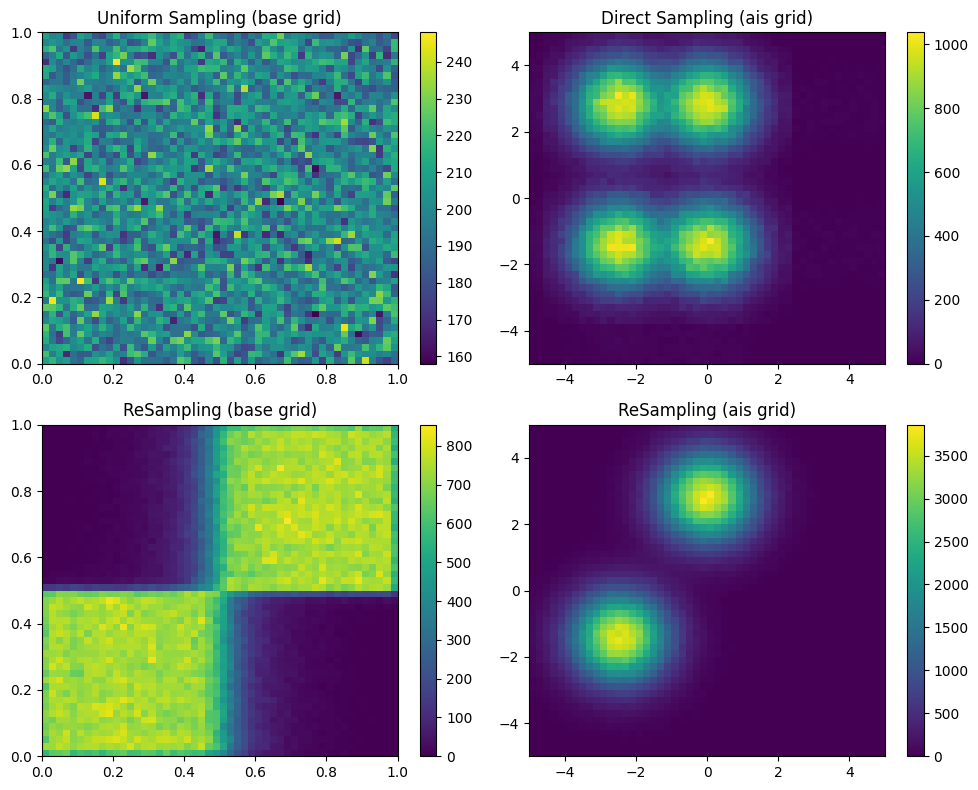

In [3]:
plot_ais(x0,x_ais,x0_resample,x_ais_resample)

In [4]:
# Schrodinger generator-flow phase   
Nit=100
# training dataset
if Nd == 12:
    Ns = 100000
    batch_size = 20000
    Nit = 200
    lr_max=1e-4
    B=2.5
    x_max =2.5
    dirsave = 'results_SG_cluster'

elif Nd == 18:
    Ns = 200000
    batch_size = 50000
    Nit = 2000
    lr_max=1e-4
    B=2.0
    x_max =2.0
    dirsave = 'results_SG_cluster'
elif Nd == 24:
    Ns = 1000000
    batch_size = 100000
    Nit = 200
    lr_max=1e-5
    B=5.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 9:
    Ns = 60000
    batch_size = 20000
    Nit=200
    lr_max=2e-4
    B=3.0
    x_max =3.0
    dirsave = 'results_SG_cluster'
elif Nd == 6:
    Ns = 60000
    batch_size = 20000
    Nit=200
    lr_max=5e-4
    B=3.0
    x_max =3.0
    dirsave = 'results_SG_cluster'
elif Nd == 2:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-3  #5e-4
    B=3.5
    x_max =3.5
    dirsave = 'results_SG_cluster'
    
elif Nd == 3:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-3  #5e-4
    B=3.5
    x_max =3.5
    dirsave = 'results_SG_cluster'    

x_train, J_vg, f_vg = SG_AIS_sampler(Ns, gdv, grid_ais, Nd,param_ais, fun_integrand,
                                  device=device, batch_size=batch_size, stratified=False)
train_loader, train_dataset = prepare_nf_training_data(x_train, batch_size=batch_size)
if device=='cpu':
    plot_training_data_2d(train_dataset, dim1=0, dim2=1, bins=100, scatter=True, hist2d=True)

    
modelA = create_flow_from_args(args=args, dim=Nd, cluster_params=cluster_params,funA=fun_integrand, device=device,fun=CustomDistribution,B=B,x_max=x_max)
model0 = copy.deepcopy(modelA).to(device)
trained_modelA, loss_hist = train_flow(model=modelA, train_loader=train_loader, Nd=Nd, epochs=args.iterations, lr_max=lr_max,device=device,dirsave=dirsave)

if device=='cpu':
    plt.figure(figsize=(10, 8))
    plt.plot(loss_hist)
    plt.title('Loss_{flow}')
    plt.show()
x_ais=x_ais.to(device)
x_train=x_train.to(device)
with torch.no_grad():
    x_ais_nf0,_,_ = model0(x_ais)
    x_ais_nf,_,_ = trained_modelA(x_ais)
    x_train_B,_,_ = trained_modelA(x_train)

if device=='cpu':
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf0)
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf)
    

Epoch 1/151 AvgLoss=6.2222 Best=6.2222
Epoch 11/151 AvgLoss=2.6003 Best=2.6003
Epoch 21/151 AvgLoss=2.4431 Best=2.4431
Epoch 31/151 AvgLoss=2.2701 Best=2.2630
Epoch 41/151 AvgLoss=2.2233 Best=2.2154
Epoch 51/151 AvgLoss=2.2192 Best=2.2154
Epoch 61/151 AvgLoss=2.1548 Best=2.1548
Epoch 71/151 AvgLoss=2.1192 Best=2.1183
Epoch 81/151 AvgLoss=2.1559 Best=2.1183
Epoch 91/151 AvgLoss=2.0976 Best=2.0884
Epoch 101/151 AvgLoss=2.0795 Best=2.0795
Epoch 111/151 AvgLoss=2.0717 Best=2.0712
Epoch 121/151 AvgLoss=2.0759 Best=2.0652
Epoch 131/151 AvgLoss=2.0703 Best=2.0652
Epoch 141/151 AvgLoss=2.0655 Best=2.0652
Epoch 151/151 AvgLoss=2.0636 Best=2.0636


In [5]:
if Nd == 12:
    Ns = 100000
    batch_size = 20000
    Nit = 100
    lr_max=1e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'

elif Nd == 18:
    Ns = 200000
    batch_size = 50000
    Nit = 1000
    lr_max=1e-4
    B=5.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 24:
    Ns = 1000000
    batch_size = 100000
    Nit = 200
    lr_max=1e-4
    B=5.5
    x_max =5.0
    dirsave = 'results_SG_cluster'
elif Nd == 9:
    Ns = 60000
    batch_size = 20000
    Nit=100
    lr_max=2e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 6:
    Ns = 40000
    batch_size = 20000
    Nit=100
    lr_max=2e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
elif Nd == 2:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-4  #5e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'
    
elif Nd == 3:
    Ns = 40000
    batch_size = 10000
    Nit=200
    lr_max=1e-4  #5e-4
    B=6.0
    x_max =4.0
    dirsave = 'results_SG_cluster'    

    
modelB = create_flow_from_args(args=args, dim=Nd, cluster_params=cluster_params,funA=fun_integrand, device=device,fun=CustomDistribution,B=B,x_max=x_max)
model1 = copy.deepcopy(modelB).to(device)
train_loader_B, train_dataset_B = prepare_nf_training_data(x_train_B, batch_size=batch_size)
if device=='cpu':
    plot_training_data_2d(train_dataset_B, dim1=0, dim2=1, bins=100, scatter=True, hist2d=True)

trained_modelB, loss_hist_B = train_flow(model=modelB, train_loader=train_loader_B, Nd=Nd, epochs=args.iterations, lr_max=lr_max,device=device,dirsave=dirsave)

x_ais_nf=x_ais_nf.to(device)
with torch.no_grad():
    x_ais_nf2,_,_ = model1(x_ais_nf)
    x_ais_nfB,_,_ = trained_modelB(x_ais_nf)
    x_train_C,_,_ = trained_modelB(x_train_B)
if device=='cpu':
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf2)
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nfB)

loss = []
loss.append(loss_hist)
loss.append(loss_hist_B)
if device=='cpu':
    plt.figure(figsize=(10, 8))
    plt.plot(loss_hist_B)
    plt.title('Loss_{flow}')
    plt.show()
    

Epoch 1/151 AvgLoss=1.6673 Best=1.6673
Epoch 11/151 AvgLoss=-0.1383 Best=-0.1383
Epoch 21/151 AvgLoss=-0.2913 Best=-0.2913
Epoch 31/151 AvgLoss=-0.3489 Best=-0.3489
Epoch 41/151 AvgLoss=-0.3783 Best=-0.3783
Epoch 51/151 AvgLoss=-0.3971 Best=-0.3971
Epoch 61/151 AvgLoss=-0.4081 Best=-0.4083
Epoch 71/151 AvgLoss=-0.4166 Best=-0.4166
Epoch 81/151 AvgLoss=-0.4257 Best=-0.4257
Epoch 91/151 AvgLoss=-0.4306 Best=-0.4307
Epoch 101/151 AvgLoss=-0.4346 Best=-0.4346
Epoch 111/151 AvgLoss=-0.4377 Best=-0.4377
Epoch 121/151 AvgLoss=-0.4392 Best=-0.4392
Epoch 131/151 AvgLoss=-0.4400 Best=-0.4400
Epoch 141/151 AvgLoss=-0.4403 Best=-0.4403
Epoch 151/151 AvgLoss=-0.4404 Best=-0.4404


In [6]:
trained_combine = CombinedFlow(trained_modelA, trained_modelB)
trained_combine.eval()

with torch.no_grad():
    x_ais_nf_combine,_ = trained_combine(x_ais)

if device=='cpu':
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nfB)
    plot_SG(x0,x_ais,x0_resample,x_ais_resample,x_ais_nf_combine)

# x_Vegas_MC--->x0_ais_resample
# x_FuHsi---> x_SG
#x_vg--->x_ais_B
#x_nf-->x_SG_nf
from srcSG_Flow import SG_sampler
Nsm=10000

if Nd>0:
    x0_ais_resample_B = []
    for k in range(15):
        x0_ais_resample_B_, status = SG_AIS_resampler(gdv, grid_ais, fun_integrand, param_ais,device=device,total_proposals=1000000,n_final=Nsm,batch_proposal=50000)
        x0_ais_resample_B.append(x0_ais_resample_B_)

    x0_ais_resample_B = torch.cat(x0_ais_resample_B, dim=0)


In [7]:
if Nd>0:
    x_SG = []
    x_SG_nf=[]
    x_ais_B=[]
    for k in range(15):
        print(k)
        x_SG_, x_ais_B_, x_SG_nf_, w_SG, f_nf, J_nf, J_ais, idx, status = SG_sampler(
            gdv,
            grid_ais,
            fun_integrand,
            param_ais,
            trained_combine,
            device=device,
            n_vegas_proposals=2_000_000,
            n_nf_proposals=2_000_000,
            n_final=10_000,
            batch_proposal=20_000,
            resample_method='systematic',
            jitter=0.0,
            ess_threshold=None
        )

        x_SG.append(x_SG_)
        #x_SG_nf.append(x_SG_nf_)
        #x_ais_B.append(x_ais_B_)

    # concatenate into a single tensor
    x_SG = torch.cat(x_SG, dim=0)
    #x_SG_nf = torch.cat(x_SG_nf, dim=0)
    #x_ais_B = torch.cat(x_ais_B, dim=0)
    x_SG_nf = x_SG_nf_
    x_ais_B  = x_ais_B_


0
max of f_FuHsi
tensor(327.0719, device='cuda:0')
tensor(1.0040, device='cuda:0')
max of f_flow
tensor(52.0521, device='cuda:0')
tensor(6.5717, device='cuda:0')
max of J_flow
tensor(1520.8066, device='cuda:0')
tensor(0.3643, device='cuda:0')
max of J_vg
tensor(35405.7625, device='cuda:0')
tensor(0.6629, device='cuda:0')
size of wFuHsi: torch.Size([2000000])
max of f_FuHsi
tensor(327.0719, device='cuda:0')
tensor(1.0040, device='cuda:0')
1
max of f_FuHsi
tensor(696.3273, device='cuda:0')
tensor(1.0042, device='cuda:0')
max of f_flow
tensor(51.9250, device='cuda:0')
tensor(6.5698, device='cuda:0')
max of J_flow
tensor(7336.1363, device='cuda:0')
tensor(0.3670, device='cuda:0')
max of J_vg
tensor(433858.8239, device='cuda:0')
tensor(1.0332, device='cuda:0')
size of wFuHsi: torch.Size([2000000])
max of f_FuHsi
tensor(696.3273, device='cuda:0')
tensor(1.0042, device='cuda:0')
2
max of f_FuHsi
tensor(190.4561, device='cuda:0')
tensor(1.0046, device='cuda:0')
max of f_flow
tensor(51.9088, de

In [8]:
with torch.no_grad():
    #x_ais_C,_ = trained_modelA.inverse(x_SG_nf)  #[0]
    x_ais_C,_ = trained_combine.inverse(x_SG_nf)

xini = SG_AIS_inverse_mapping(x_ais_C, param_ais,Nd,gdv,grid_ais)

with torch.no_grad():
    #x_resample_ais,_ = trained_modelA.inverse(x_SG) #[0]
    x_resample_ais,_ = trained_combine.inverse(x_SG) #[0]
    #x_resample_vg = flow.inverse(x_nf)[0]

x_resample_ini = SG_AIS_inverse_mapping(x_resample_ais, param_ais,Nd,gdv,grid_ais)


#plot_SG_full(xini,x_ais_C,x_SG_nf,x0_ais_resample_B,x_resample_ini,x_resample_ais,x_SG)

dsave = {
    "xini": xini,
    "xvegas": x_ais_C,
    "xflow": x_SG_nf,
    "xvegasR":x0_ais_resample_B,
    "xflowR":x_SG,
    "xflowR-vg":x_resample_ais,
    "xflowR-ini":x_resample_ini
}

torch.save(dsave, "results/SG_cluster_save_" + str(Nd) + "d.dat")
    #Z = flow.forward(Y) 


Ns = 2000000
X= torch.rand((Ns, Nd), dtype=dtype, device=device)

Y,J_vg = SG_AIS_mapping(X, param_ais,Nd,gdv,grid_ais, device=device,return_jacobian=True)

X1 = SG_AIS_inverse_mapping(Y, param_ais,Nd,gdv,grid_ais)

with torch.no_grad():
    #Z, log_q_nf= trained_modelA.forward_with_logdet(Y)
    Z, log_q_nf= trained_combine.forward_with_logdet(Y)
    Z_A, log_q_nf_A= trained_modelA.forward_with_logdet(Y)



In [9]:
Nd

6

In [10]:
J_nf = torch.exp(-log_q_nf)
J_nf_A = torch.exp(-log_q_nf_A)
s_nf = (Z - a) / (b - a)
s_nf_A = (Z_A - a) / (b - a)
s_ais = (Y - a) / (b - a)
vol = torch.prod(b - a)
f_ais0,_ = fun_integrand(s_ais,param_ais)
f_ais0=f_ais0.to(dtype)
f_ais = f_ais0/vol*J_vg/Iscal
I_ais = f_ais.mean()
err_ais = f_ais.std()/np.sqrt(Ns)

f_nf,_ = fun_integrand(s_nf, param_ais)
f_nf=f_nf.to(dtype)
f_nf_A,_ = fun_integrand(s_nf_A, param_ais)
f_nf_A = f_nf_A.to(dtype)
f_SG = (f_nf/vol*J_vg/Iscal)*J_nf
f_SG_A = (f_nf_A/vol*J_vg/Iscal)*J_nf_A
#I_FuHsi = f_FuHsi[f_FuHsi<300].mean()
#err_FuHsi = f_FuHsi[f_FuHsi<300].std()/np.sqrt(Ns)

I_SG = f_SG.mean()
err_SG = f_SG.std()/np.sqrt(Ns)
I_SG_A = f_SG_A.mean()
err_SG_A = f_SG_A.std()/np.sqrt(Ns)
print("Nd = ",Nd)
print("Monte Carlo 积分近似结果:",  I_ais, err_ais,  I_SG_A, err_SG_A, I_SG, err_SG)

fmax,idx = torch.max(f_SG, dim=0)
print(f_nf[idx])
print(J_vg[idx])
print(J_nf[idx])

f_ini,_ = fun_integrand(xini, param_ais)
#print(f_ini)
#print(Iscal)
f_ini = f_ini/Iscal


Nd =  6
Monte Carlo 积分近似结果: tensor(0.9999, device='cuda:0') tensor(0.0016, device='cuda:0') tensor(1.0039, device='cuda:0') tensor(0.0008, device='cuda:0') tensor(1.0040, device='cuda:0') tensor(0.0007, device='cuda:0')
tensor(1098896.7524, device='cuda:0')
tensor(47184.9700, device='cuda:0')
tensor(333.5142, device='cuda:0')


SG-Uniform: Loss =  tensor(15.7461, device='cuda:0')
SG-vg: Loss =  tensor(5.4809, device='cuda:0')
SG-NF: LossA =  tensor(1.2716, device='cuda:0')
SG-NF: Loss =  tensor(0.1575, device='cuda:0')


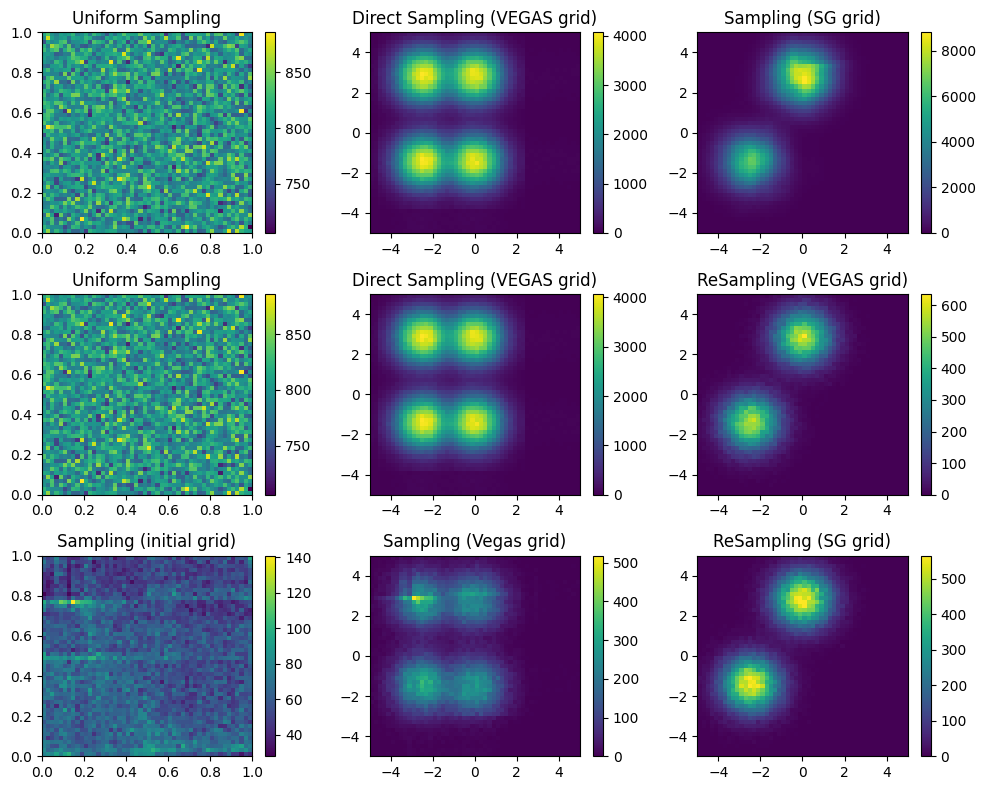

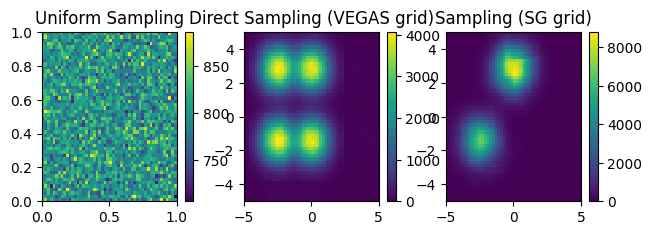

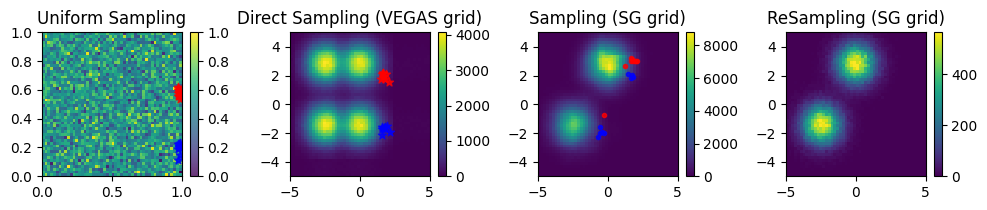

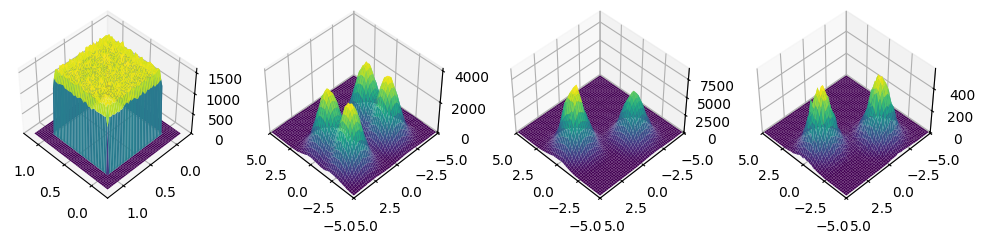

In [11]:
Loss_KL_ini = -torch.log(f_ini).mean()
Loss_KL_ini_std = torch.log(f_ini).std()
Loss_KL_ais = -torch.log(f_ais).mean()
Loss_KL_sg = -torch.log(f_SG).mean()
Loss_KL_sg_A = -torch.log(f_SG_A).mean()
print("SG-Uniform: Loss = ",  Loss_KL_ini)
print("SG-vg: Loss = ",  Loss_KL_ais)
print("SG-NF: LossA = ",  Loss_KL_sg_A)
print("SG-NF: Loss = ",  Loss_KL_sg)

with open("results/SG_cluster_result_" + str(Nd) + "d.dat", "w") as f:
    f.write(f"Monte Carlo Integral: "
            f"{I_ais} {err_ais} {I_SG_A} {err_SG_A} {I_SG} {err_SG}\n")
    f.write(f"SG-Uniform: Loss = {Loss_KL_ini}\n")
    f.write(f"SG-vg: Loss = {Loss_KL_ais}\n")
    f.write(f"SG-NF: LossA = {Loss_KL_sg_A}\n")
    f.write(f"SG-NF: Loss = {Loss_KL_sg}\n")


plot_SG_full(xini,x_ais_C,x_SG_nf,x0_ais_resample_B,x_resample_ini,x_resample_ais,x_SG)
